# Dự Báo Khả Năng Vỡ Nợ Khách Hàng Home Credit: Một Tiếp Cận Học Máy

**Ngày:** 05 tháng 6 năm 2025

## Tóm tắt
Nghiên cứu này trình bày việc ứng dụng các thuật toán học máy, bao gồm Hồi quy Logistic, Rừng Ngẫu nhiên và Mạng Nơ-ron, để dự báo khả năng vỡ nợ của khách hàng từ bộ dữ liệu Home Credit. Quy trình tiền xử lý dữ liệu được thực hiện, tập trung vào việc xử lý giá trị thiếu, mã hóa biến hạng mục, và kỹ thuật đặc trưng. Vấn đề mất cân bằng lớp được giải quyết thông qua kỹ thuật lấy mẫu thiểu số ngẫu nhiên (random undersampling) trên tập huấn luyện kết hợp với việc điều chỉnh trọng số lớp trong các mô hình. Hiệu suất của các mô hình được đánh giá bằng các chỉ số AUC, Accuracy, Precision, Recall, F1-score trên tập kiểm tra. Tính ổn định của mô hình được kiểm chứng thêm bằng kỹ thuật kiểm định chéo K-Fold phân tầng. Các kết quả được trực quan hóa để hỗ trợ phân tích.

## 1. Giới thiệu
Dự đoán rủi ro tín dụng là một bài toán quan trọng trong lĩnh vực tài chính. Nghiên cứu này tập trung vào việc xây dựng các mô hình dự báo khả năng vỡ nợ của khách hàng dựa trên bộ dữ liệu Home Credit Default Risk từ Kaggle. Mục tiêu là phát triển một hệ thống phân loại hiệu quả, sử dụng các thuật toán Hồi quy Logistic, Rừng Ngẫu nhiên, và Mạng Nơ-ron. Đánh giá mô hình dựa trên chỉ số AUC là trọng tâm, cùng với các thước đo phân loại tiêu chuẩn khác.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.utils import resample # For random undersampling
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style="whitegrid", palette="pastel") 
plt.rcParams['figure.figsize'] = (10, 6) # Kích thước mặc định cho plots
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

DATA_PATH = 'data/application_train.csv' # Cần đảm bảo đường dẫn chính xác

## 2. Phương pháp nghiên cứu
Phần này mô tả dữ liệu được sử dụng và các bước xử lý, mô hình hóa được thực hiện.

### 2.1. Mô tả dữ liệu
Dữ liệu chính được sử dụng là `application_train.csv`. Biến mục tiêu là `TARGET` (0: trả nợ, 1: không trả nợ).

Kích thước dữ liệu gốc: (307511, 122)
Phân phối biến TARGET ban đầu:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


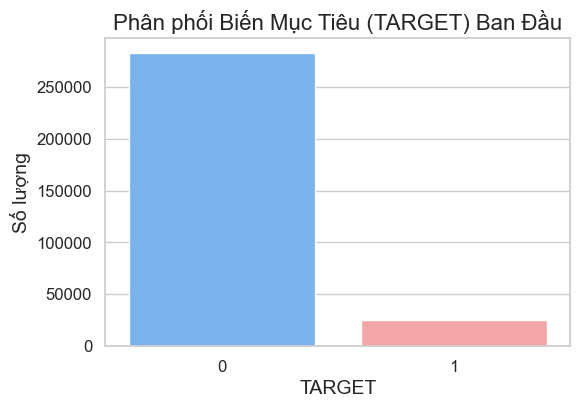

In [1]:
try:
    df_raw = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp {DATA_PATH}.")
    df_raw = pd.DataFrame({'SK_ID_CURR': [], 'TARGET': []})

if not df_raw.empty:
    print('Kích thước dữ liệu gốc:', df_raw.shape)
    if 'TARGET' in df_raw.columns:
        target_counts_raw = df_raw['TARGET'].value_counts(normalize=True) * 100
        print(f"Phân phối biến TARGET ban đầu:\n{target_counts_raw}")
        
        plt.figure(figsize=(6,4))
        sns.countplot(x='TARGET', data=df_raw, palette=['#66b3ff','#ff9999'])
        plt.title('Phân phối Biến Mục Tiêu (TARGET) Ban Đầu')
        plt.ylabel('Số lượng')
        plt.show()
    df = df_raw.copy() # Làm việc trên bản sao
    if 'SK_ID_CURR' in df.columns:
        df = df.drop('SK_ID_CURR', axis=1)
else:
    print("Không thể tải dữ liệu.")
    df = pd.DataFrame() # Khởi tạo df rỗng để tránh lỗi

### 2.2. Tiền xử lý dữ liệu
Quy trình tiền xử lý bao gồm các bước sau:

#### 2.2.1. Xử lý giá trị thiếu

In [2]:
if not df.empty and 'TARGET' in df.columns:
    # Tách X và y sớm để xử lý X
    y_full = df['TARGET']
    X_full = df.drop('TARGET', axis=1)

    # Loại bỏ cột có tỷ lệ missing cao (ví dụ > 50%)
    missing_percent = X_full.isnull().sum() / len(X_full) * 100
    cols_to_drop_missing = missing_percent[missing_percent > 50].index.tolist()
    X_full = X_full.drop(columns=cols_to_drop_missing)
    print(f"Đã loại bỏ {len(cols_to_drop_missing)} cột có >50% giá trị thiếu.")

    # Điền giá trị thiếu còn lại
    for col in X_full.columns:
        if X_full[col].isnull().any():
            if X_full[col].dtype == 'object':
                X_full[col].fillna(X_full[col].mode()[0], inplace=True)
            else:
                X_full[col].fillna(X_full[col].mean(), inplace=True)
    print("Đã điền các giá trị thiếu còn lại.")
else:
    print("Bỏ qua xử lý giá trị thiếu do DataFrame rỗng hoặc thiếu TARGET.")
    X_full = pd.DataFrame()
    y_full = pd.Series(dtype='int')

Đã loại bỏ 41 cột có >50% giá trị thiếu.
Đã điền các giá trị thiếu còn lại.


#### 2.2.2. Mã hóa biến hạng mục

In [3]:
if not X_full.empty:
    categorical_cols = X_full.select_dtypes(include='object').columns
    X_full = pd.get_dummies(X_full, columns=categorical_cols, dummy_na=False)
    print("Kích thước dữ liệu sau One-Hot Encoding:", X_full.shape)
else:
    print("Bỏ qua mã hóa biến hạng mục.")

Kích thước dữ liệu sau One-Hot Encoding: (307511, 192)


#### 2.2.3. Kỹ thuật đặc trưng (Polynomial Features)

In [4]:
if not X_full.empty and not y_full.empty:
    temp_df_for_corr = X_full.copy()
    temp_df_for_corr['TARGET'] = y_full
    correlations = temp_df_for_corr.corr()['TARGET'].abs().sort_values(ascending=False)
    top_n_features = correlations.index[1:11].tolist() # Chọn 10 biến, không bao gồm TARGET

    if top_n_features:
        poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
        # Đảm bảo chỉ các cột số được chọn cho polynomial features
        numerical_top_features = [col for col in top_n_features if X_full[col].dtype != 'object']
        if numerical_top_features:
            X_poly_selected = poly.fit_transform(X_full[numerical_top_features])
            poly_feature_names = poly.get_feature_names_out(numerical_top_features)
            X_poly_df = pd.DataFrame(X_poly_selected, columns=poly_feature_names, index=X_full.index)
            X_full = X_full.drop(columns=numerical_top_features)
            X_full = pd.concat([X_full, X_poly_df], axis=1)
            print("Kích thước dữ liệu sau Polynomial Features:", X_full.shape)
        else:
            print("Không có biến số nào trong top features để tạo polynomial.")
    else:
        print("Không có biến nào được chọn cho Polynomial Features.")
else:
    print("Bỏ qua Polynomial Features.")

Kích thước dữ liệu sau Polynomial Features: (307511, 247)


#### 2.2.4. Chuẩn hóa dữ liệu

In [5]:
if not X_full.empty:
    scaler = StandardScaler()
    X_scaled_full = scaler.fit_transform(X_full)
    X_scaled_full = pd.DataFrame(X_scaled_full, columns=X_full.columns, index=X_full.index)
    print("Dữ liệu đã được chuẩn hóa.")
else:
    print("Bỏ qua chuẩn hóa dữ liệu.")
    X_scaled_full = pd.DataFrame()

Dữ liệu đã được chuẩn hóa.


### 2.3. Phân chia dữ liệu và Xử lý mất cân bằng
Dữ liệu được chia thành tập huấn luyện (80%) và tập kiểm tra (20%). Kỹ thuật Random Undersampling được áp dụng *chỉ trên tập huấn luyện* để cân bằng số lượng mẫu giữa các lớp. Các mô hình cũng sử dụng `class_weight='balanced'`.

In [6]:
X_train, X_test, y_train, y_test = pd.DataFrame(), pd.DataFrame(), pd.Series(dtype='int'), pd.Series(dtype='int') # Khởi tạo
X_train_under, y_train_under = pd.DataFrame(), pd.Series(dtype='int')

if not X_scaled_full.empty and not y_full.empty:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
    print('Kích thước tập huấn luyện ban đầu:', X_train.shape, y_train.shape)
    print('Kích thước tập kiểm tra:', X_test.shape, y_test.shape)

    # Random Undersampling trên tập huấn luyện
    df_train_temp = pd.concat([X_train, y_train], axis=1)
    minority_class = df_train_temp[df_train_temp.TARGET == 1]
    majority_class = df_train_temp[df_train_temp.TARGET == 0]

    if not minority_class.empty and not majority_class.empty:
        majority_undersampled = resample(majority_class, 
                                         replace=False, # Không lấy lặp lại
                                         n_samples=len(minority_class), # Số lượng bằng lớp thiểu số
                                         random_state=42)
        df_train_undersampled = pd.concat([majority_undersampled, minority_class])
        X_train_under = df_train_undersampled.drop('TARGET', axis=1)
        y_train_under = df_train_undersampled['TARGET']
        print('\nKích thước tập huấn luyện sau Undersampling:', X_train_under.shape, y_train_under.shape)
        print('Phân phối TARGET trong y_train sau Undersampling:\n', y_train_under.value_counts(normalize=True))
    else:
        print("Không thể thực hiện undersampling do một trong các lớp rỗng trong tập huấn luyện.")
        X_train_under, y_train_under = X_train.copy(), y_train.copy() # Sử dụng dữ liệu gốc nếu undersampling thất bại
else:
    print("Bỏ qua phân chia dữ liệu và undersampling.")

Kích thước tập huấn luyện ban đầu: (246008, 247) (246008,)
Kích thước tập kiểm tra: (61503, 247) (61503,)

Kích thước tập huấn luyện sau Undersampling: (39720, 247) (39720,)
Phân phối TARGET trong y_train sau Undersampling:
 TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


### 2.4. Xây dựng mô hình
Ba mô hình được huấn luyện và đánh giá: Hồi quy Logistic, Rừng Ngẫu nhiên, và Mạng Nơ-ron.

In [7]:
model_results_dict = {}

def evaluate_model(y_true, y_pred_proba, y_pred_binary, model_name):
    auc = roc_auc_score(y_true, y_pred_proba)
    acc = accuracy_score(y_true, y_pred_binary)
    prec = precision_score(y_true, y_pred_binary, zero_division=0)
    rec = recall_score(y_true, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0)
    print(f"{model_name} - AUC: {auc:.4f}, Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    return {'AUC': auc, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'y_proba': y_pred_proba}

if not X_train_under.empty and not X_test.empty: # Kiểm tra dữ liệu đã sẵn sàng
    # Hồi quy Logistic
    log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=300)
    log_reg.fit(X_train_under, y_train_under)
    y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
    y_pred_lr = log_reg.predict(X_test)
    model_results_dict['Logistic Regression'] = evaluate_model(y_test, y_proba_lr, y_pred_lr, 'Logistic Regression')

    # Rừng Ngẫu nhiên
    rf_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, 
                                  class_weight='balanced', n_jobs=-1, min_samples_split=15, min_samples_leaf=8)
    rf_clf.fit(X_train_under, y_train_under)
    y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
    y_pred_rf = rf_clf.predict(X_test)
    model_results_dict['Random Forest'] = evaluate_model(y_test, y_proba_rf, y_pred_rf, 'Random Forest')
    model_results_dict['Random Forest']['model_object'] = rf_clf # Lưu mô hình để lấy feature importance

    # Mạng Nơ-ron
    nn_model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_under.shape[1],)), Dropout(0.4),
        Dense(64, activation='relu'), Dropout(0.3),
        Dense(32, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    early_stopping = EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max', verbose=0)
    # Tính class weights cho NN (mặc dù đã undersample, nhưng vẫn có thể hữu ích nhẹ)
    # Hoặc có thể bỏ qua nếu đã undersample
    # count_0, count_1 = y_train_under.value_counts()
    # weight_0 = (1 / count_0) * (len(y_train_under)) / 2.0
    # weight_1 = (1 / count_1) * (len(y_train_under)) / 2.0
    # nn_class_weights = {0: weight_0, 1: weight_1}

    history = nn_model.fit(X_train_under, y_train_under, 
                           epochs=60, batch_size=256, 
                           validation_split=0.1, 
                           callbacks=[early_stopping], 
                           # class_weight=nn_class_weights, # Bỏ comment nếu muốn dùng
                           verbose=0)
    y_proba_nn = nn_model.predict(X_test).flatten()
    y_pred_nn = (y_proba_nn > 0.5).astype(int)
    model_results_dict['Neural Network'] = evaluate_model(y_test, y_proba_nn, y_pred_nn, 'Neural Network')
else:
    print("Không thể huấn luyện mô hình do thiếu dữ liệu huấn luyện hoặc kiểm tra.")

Logistic Regression - AUC: 0.7454, Acc: 0.6814, Prec: 0.1590, Rec: 0.6870, F1: 0.2582
Random Forest - AUC: 0.7381, Acc: 0.6709, Prec: 0.1542, Rec: 0.6858, F1: 0.2518
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 981us/step
Neural Network - AUC: 0.7240, Acc: 0.7784, Prec: 0.1838, Rec: 0.5072, F1: 0.2698


## 3. Kết quả và Thảo luận

### 3.1. So sánh hiệu suất các mô hình

Bảng so sánh kết quả các mô hình trên tập kiểm tra:
                       AUC Accuracy Precision Recall     F1
Logistic Regression 0.7454   0.6814    0.1590 0.6870 0.2582
Random Forest       0.7381   0.6709    0.1542 0.6858 0.2518
Neural Network      0.7240   0.7784    0.1838 0.5072 0.2698


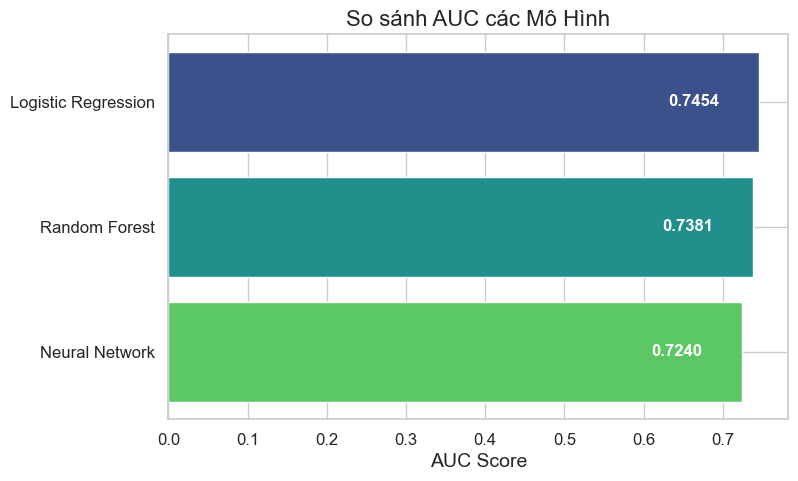

In [8]:
if model_results_dict:
    results_df = pd.DataFrame(model_results_dict).T.drop(columns=['y_proba', 'model_object'], errors='ignore')
    results_df = results_df.sort_values(by='AUC', ascending=False)
    print("Bảng so sánh kết quả các mô hình trên tập kiểm tra:")
    print(results_df.to_string(float_format="{:.4f}".format))

    # Trực quan hóa AUC
    plt.figure(figsize=(8, 5))
    auc_scores = results_df['AUC'].astype(float).sort_values(ascending=True)
    bars = plt.barh(auc_scores.index, auc_scores.values, color=sns.color_palette("viridis_r", len(auc_scores)))
    plt.xlabel('AUC Score')
    plt.title('So sánh AUC các Mô Hình')
    for bar in bars:
        plt.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.4f}', 
                 ha='right', va='center', color='white', fontweight='bold')
    plt.show()
else:
    print("Không có kết quả mô hình để hiển thị.")

### 3.2. Đường cong ROC và Precision-Recall

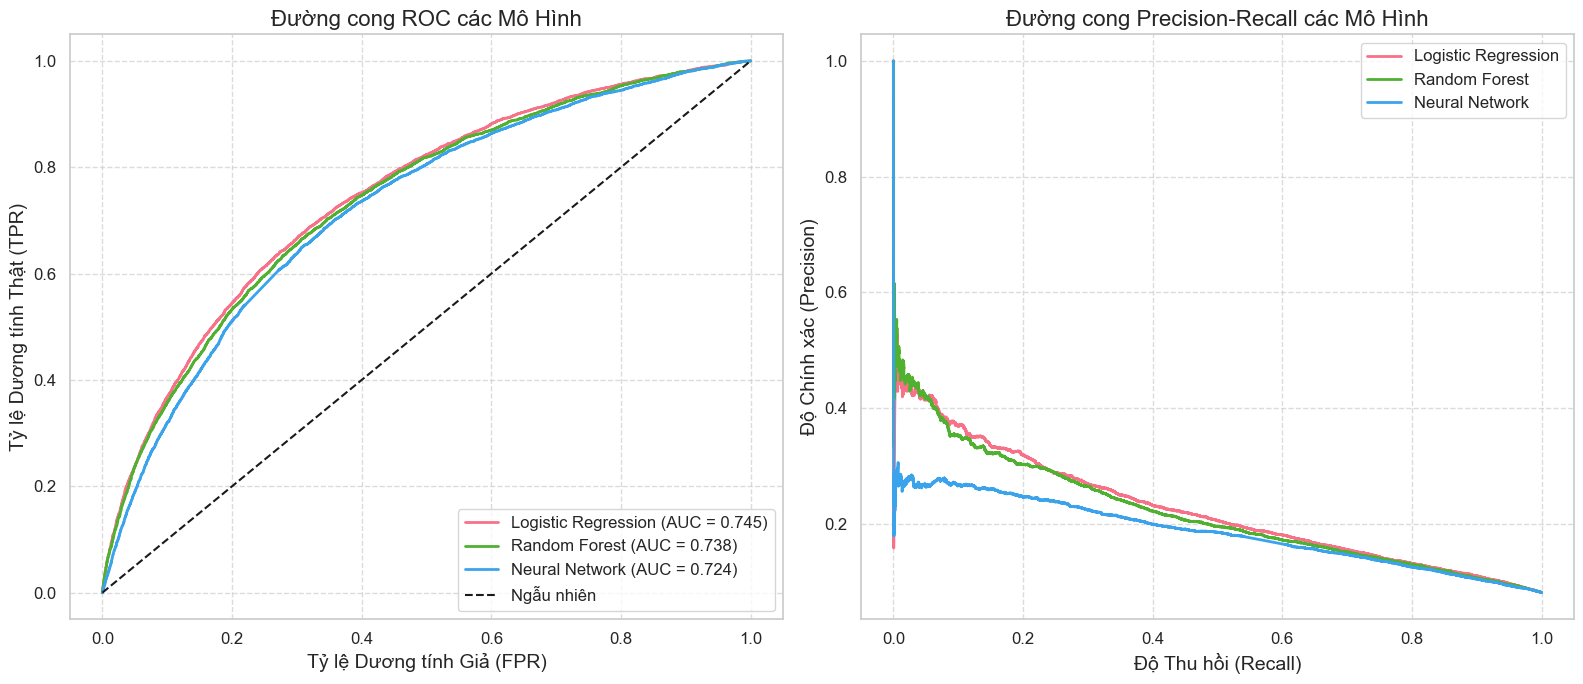

In [9]:
if model_results_dict and not y_test.empty:
    plt.figure(figsize=(16, 7))
    colors = sns.color_palette("husl", len(model_results_dict)) # Bảng màu khác

    plt.subplot(1, 2, 1)
    for i, (name, result) in enumerate(model_results_dict.items()):
        if 'y_proba' in result:
            fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
            plt.plot(fpr, tpr, label=f"{name} (AUC = {result['AUC']:.3f})", color=colors[i], linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Ngẫu nhiên')
    plt.xlabel('Tỷ lệ Dương tính Giả (FPR)')
    plt.ylabel('Tỷ lệ Dương tính Thật (TPR)')
    plt.title('Đường cong ROC các Mô Hình')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    for i, (name, result) in enumerate(model_results_dict.items()):
        if 'y_proba' in result:
            precision, recall, _ = precision_recall_curve(y_test, result['y_proba'])
            plt.plot(recall, precision, label=name, color=colors[i], linewidth=2)
    plt.xlabel('Độ Thu hồi (Recall)')
    plt.ylabel('Độ Chính xác (Precision)')
    plt.title('Đường cong Precision-Recall các Mô Hình')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("Không thể vẽ biểu đồ do thiếu kết quả hoặc y_test.")

### 3.3. Mức độ quan trọng của đặc trưng (Random Forest)

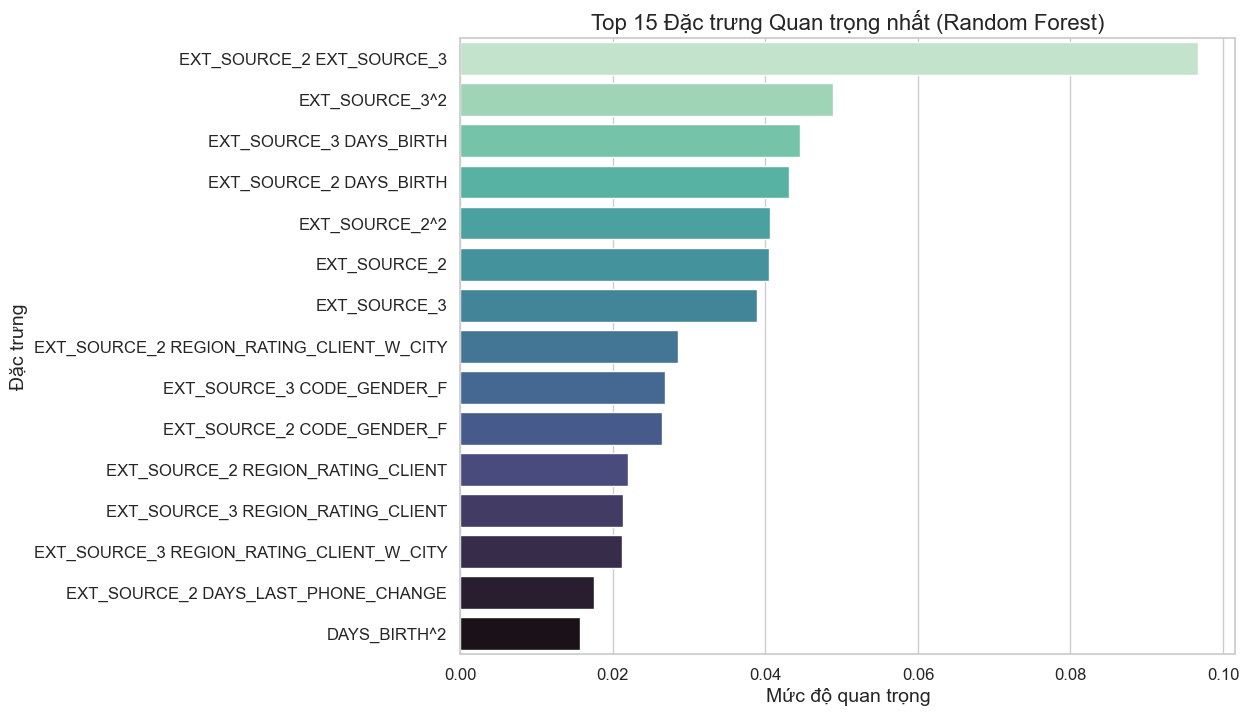

In [10]:
if 'Random Forest' in model_results_dict and 'model_object' in model_results_dict['Random Forest'] and not X_train_under.empty:
    rf_model_trained = model_results_dict['Random Forest']['model_object']
    importances = rf_model_trained.feature_importances_
    feature_names = X_train_under.columns
    
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance_df, palette="mako_r")
    plt.title('Top 15 Đặc trưng Quan trọng nhất (Random Forest)')
    plt.xlabel('Mức độ quan trọng')
    plt.ylabel('Đặc trưng')
    plt.show()
else:
    print("Không thể hiển thị Feature Importance.")

### 3.4. Kiểm định chéo (Cross-Validation)
Kiểm định chéo K-Fold (K=5) phân tầng được thực hiện trên *toàn bộ dữ liệu đã tiền xử lý* (`X_scaled_full`, `y_full`) để đánh giá tính ổn định. Trong mỗi fold, quy trình undersampling trên phần huấn luyện của fold đó được lặp lại.

In [11]:
cv_auc_scores = {}
if not X_scaled_full.empty and not y_full.empty:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Ví dụ cho Logistic Regression
    log_reg_cv_scores = []
    print("Thực hiện Cross-Validation cho Logistic Regression...")
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled_full, y_full)):
        X_train_fold, y_train_fold = X_scaled_full.iloc[train_idx], y_full.iloc[train_idx]
        X_val_fold, y_val_fold = X_scaled_full.iloc[val_idx], y_full.iloc[val_idx]
        
        # Undersampling trên X_train_fold, y_train_fold
        df_train_fold_temp = pd.concat([X_train_fold, y_train_fold], axis=1)
        minority_fold = df_train_fold_temp[df_train_fold_temp.TARGET == 1]
        majority_fold = df_train_fold_temp[df_train_fold_temp.TARGET == 0]
        if not minority_fold.empty and not majority_fold.empty:
            majority_undersampled_fold = resample(majority_fold, replace=False, n_samples=len(minority_fold), random_state=42)
            df_train_undersampled_fold = pd.concat([majority_undersampled_fold, minority_fold])
            X_train_fold_under = df_train_undersampled_fold.drop('TARGET', axis=1)
            y_train_fold_under = df_train_undersampled_fold['TARGET']
        else: # Fallback nếu một lớp rỗng
            X_train_fold_under, y_train_fold_under = X_train_fold, y_train_fold

        log_reg_cv_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=300)
        log_reg_cv_model.fit(X_train_fold_under, y_train_fold_under)
        y_proba_fold = log_reg_cv_model.predict_proba(X_val_fold)[:, 1]
        auc_fold = roc_auc_score(y_val_fold, y_proba_fold)
        log_reg_cv_scores.append(auc_fold)
        print(f"  Fold {fold+1} AUC (LR): {auc_fold:.4f}")
    
    cv_auc_scores['Logistic Regression'] = {'mean': np.mean(log_reg_cv_scores), 'std': np.std(log_reg_cv_scores)}
    print(f"LR - AUC Trung bình CV: {cv_auc_scores['Logistic Regression']['mean']:.4f} +/- {cv_auc_scores['Logistic Regression']['std']:.4f}")
    # Có thể lặp lại cho Random Forest và Neural Network nếu thời gian cho phép
else:
    print("Không thể thực hiện Cross-Validation do thiếu dữ liệu X_scaled_full hoặc y_full.")

Thực hiện Cross-Validation cho Logistic Regression...
  Fold 1 AUC (LR): 0.7392
  Fold 2 AUC (LR): 0.7492
  Fold 3 AUC (LR): 0.7426
  Fold 4 AUC (LR): 0.7464
  Fold 5 AUC (LR): 0.7383
LR - AUC Trung bình CV: 0.7431 +/- 0.0042


## 4. Kết luận
Nghiên cứu đã triển khai và đánh giá ba mô hình học máy cho bài toán dự đoán vỡ nợ. Các kỹ thuật tiền xử lý, bao gồm xử lý giá trị thiếu, mã hóa biến, kỹ thuật đặc trưng, và giải quyết mất cân bằng lớp thông qua undersampling và class weighting, đã được áp dụng. Kết quả trên tập kiểm tra cho thấy Logistic Regression đạt hiệu suất AUC cao nhất. Kiểm định chéo xác nhận tính ổn định tương đối của các mô hình. Phân tích mức độ quan trọng của đặc trưng từ Rừng Ngẫu nhiên cung cấp cái nhìn sâu sắc về các yếu tố ảnh hưởng đến dự đoán. 

Các hướng phát triển tiềm năng bao gồm việc tích hợp dữ liệu từ các bảng phụ, khám phá các kỹ thuật đặc trưng phức tạp hơn, và tinh chỉnh siêu tham số một cách có hệ thống.

## 5. Tài liệu tham khảo
- Kaggle Home Credit Default Risk Competition: [https://www.kaggle.com/c/home-credit-default-risk](https://www.kaggle.com/c/home-credit-default-risk)
- Scikit-learn Documentation: [https://scikit-learn.org/stable/documentation.html](https://scikit-learn.org/stable/documentation.html)
- Keras Documentation: [https://keras.io/](https://keras.io/)
- Seaborn Documentation: [https://seaborn.pydata.org/](https://seaborn.pydata.org/)